# Rossmann Store Sales — Linear Regression Analysis

Bohdan Pavlyshenko (https://www.linkedin.com/in/bpavlyshenko) 

**Dataset:** [Kaggle — Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales)

---

## Overview

The Rossmann dataset contains daily sales records for 100 drug-store branches across Germany.
We predict `logSales` — the natural log of daily sales — from store-level and calendar features
using **Linear Regression** and its regularised variants **Lasso** (L1) and **Ridge** (L2).

**Learning objectives:**
- Preprocess categorical time features with One-Hot Encoding
- Train and compare linear regression models with L1/L2 regularisation
- Interpret Lasso coefficients as a feature selection mechanism
- Evaluate models with RMSE, MAE, and R²


In [19]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 1. Helper Functions


In [20]:
def evaluate_regression(y_true, y_pred, name="Model"):
    """Print MAE, RMSE, and R² for a regression model.

    Args:
        y_true (array-like): Ground-truth values.
        y_pred (array-like): Predicted values.
        name (str): Model label for display. Defaults to "Model".

    Returns:
        dict: Keys 'mae', 'rmse', 'r2'.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s} | MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}


## 2. Data Loading

The pre-processed dataset contains daily records for 100 Rossmann stores.
Training data covers **2013–2014**; test data covers **January–July 2015**.

### Engineered features already in the dataset
| Feature | Description |
|---------|-------------|
| `logSales` | Natural log of daily sales (target) |
| `logMonthSales` | Log of monthly store sales (trailing average) |
| `weekday` | Day of week (0=Mon … 6=Sun) |
| `monthday` | Day of month |
| `month` | Month |
| `year` | Year |


In [21]:
train_df = pd.read_csv("data/rossm_train_df.csv")
test_df  = pd.read_csv("data/rossm_test_df.csv")

train_df["Date"] = pd.to_datetime(train_df["Date"])
test_df["Date"]  = pd.to_datetime(test_df["Date"])

print(f"Train shape: {train_df.shape}, date range: {train_df.Date.min().date()} to {train_df.Date.max().date()}")
print(f"Test shape : {test_df.shape},  date range: {test_df.Date.min().date()} to {test_df.Date.max().date()}")


Train shape: (73000, 18), date range: 2013-01-01 to 2014-12-31
Test shape : (21200, 18),  date range: 2015-01-01 to 2015-07-31


In [22]:
train_df.head()


,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,weekday,monthday,month,year,logSales,monthSales,logMonthSales
0,11,2014-12-31,3838,543,1.0,0.0,0,1.0,a,c,960.0,2,31,12,2014,8.252967,203106.000000,12.221488
1,12,2014-12-31,4871,609,1.0,0.0,0,1.0,a,c,1070.0,2,31,12,2014,8.491260,191943.387097,12.164961
2,17,2014-12-31,2639,367,1.0,0.0,0,1.0,a,a,50.0,2,31,12,2014,7.878534,159822.193548,11.981823
3,25,2014-12-31,7771,925,1.0,0.0,0,1.0,c,a,430.0,2,31,12,2014,8.958283,270211.516129,12.506964
4,31,2014-12-31,3150,363,1.0,0.0,0,1.0,d,c,9800.0,2,31,12,2014,8.055475,148262.677419,11.906748


## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution


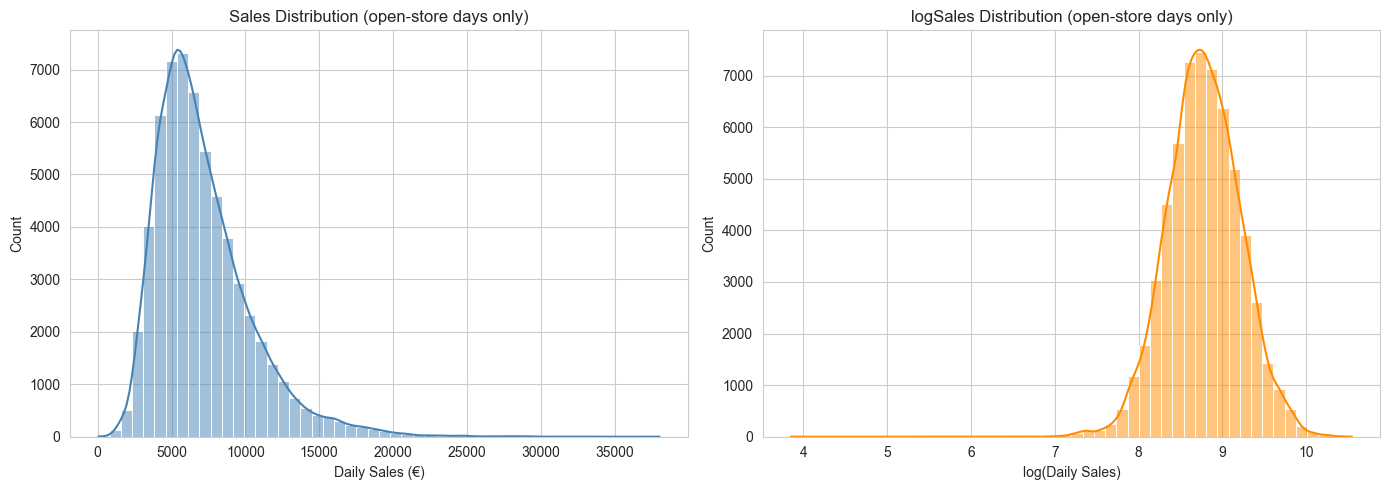

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["Sales"].replace(0, np.nan).dropna(),
             ax=axes[0], kde=True, bins=50, color="steelblue")
axes[0].set_title("Sales Distribution (open-store days only)")
axes[0].set_xlabel("Daily Sales (€)")

sns.histplot(
    train_df.loc[train_df["Sales"] > 0, "logSales"],
    ax=axes[1], kde=True, bins=50, color="darkorange"
)
axes[1].set_title("logSales Distribution (open-store days only)")
axes[1].set_xlabel("log(Daily Sales)")

plt.tight_layout()
plt.show()


### 3.2 Sales Patterns by Calendar Features


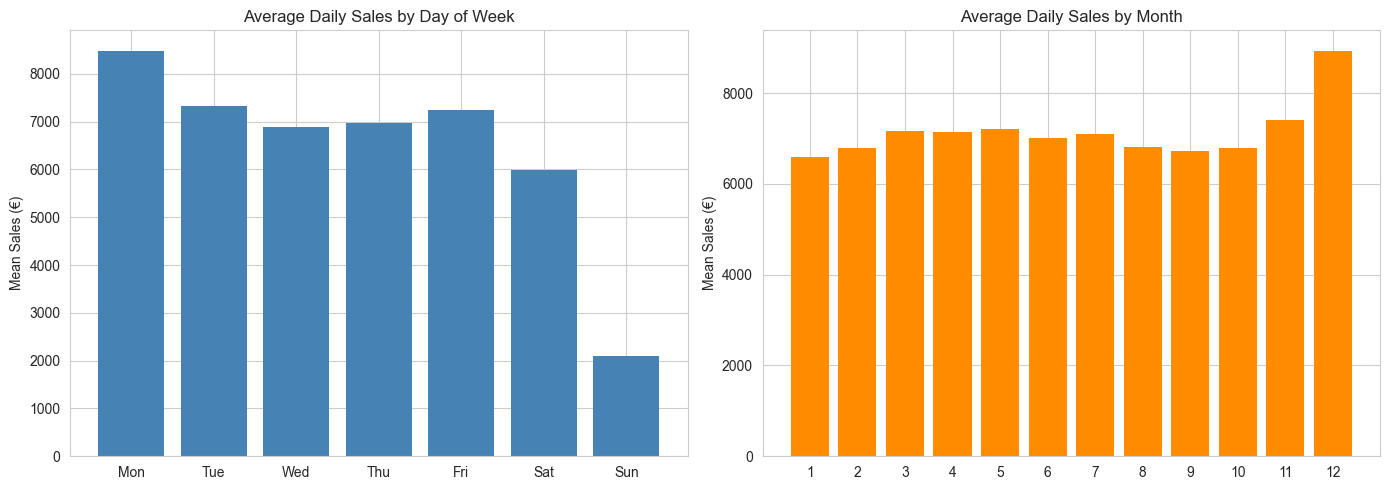

In [24]:
open_train = train_df[train_df["Open"] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = open_train.groupby("weekday")["Sales"].mean()
axes[0].bar(dow_avg.index, dow_avg.values, color="steelblue", edgecolor="none")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_title("Average Daily Sales by Day of Week")
axes[0].set_ylabel("Mean Sales (€)")

month_avg = open_train.groupby("month")["Sales"].mean()
axes[1].bar(month_avg.index, month_avg.values, color="darkorange", edgecolor="none")
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Average Daily Sales by Month")
axes[1].set_ylabel("Mean Sales (€)")

plt.tight_layout()
plt.show()


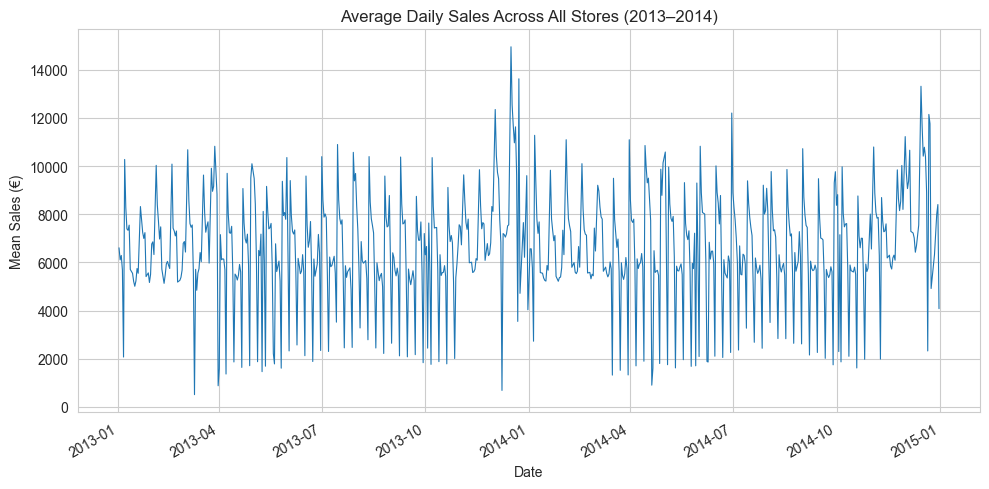

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
open_train.groupby("Date")["Sales"].mean().plot(ax=ax, linewidth=0.8)
ax.set_title("Average Daily Sales Across All Stores (2013–2014)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Sales (€)")
plt.tight_layout()
plt.show()


### 3.3 Promo and Holiday Effects


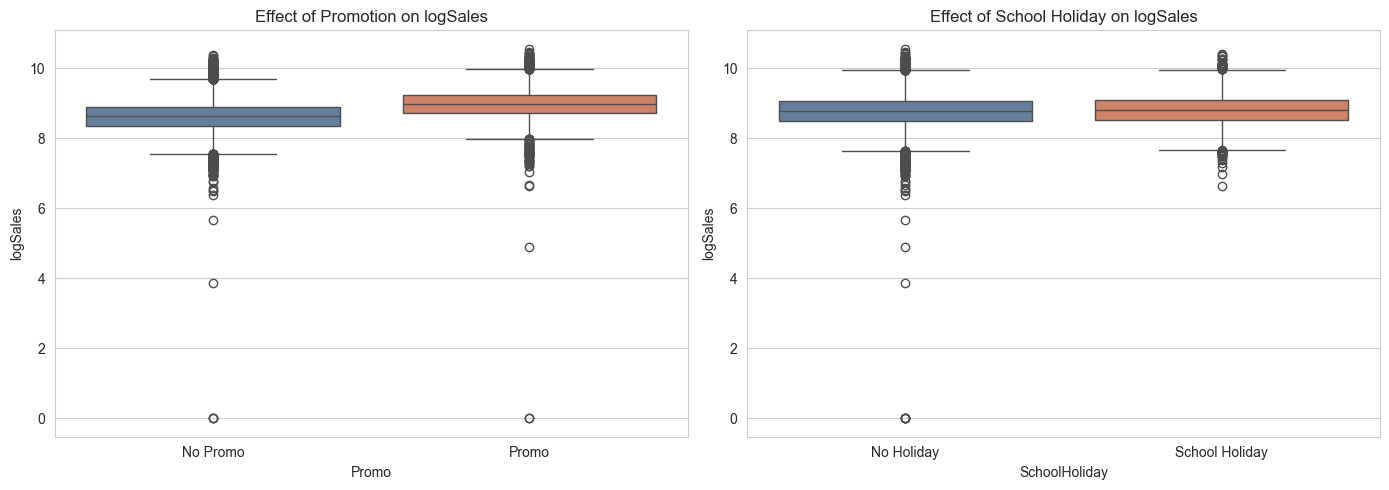

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Promo", y="logSales", data=open_train, ax=axes[0], palette=["#5b7fa6", "#e07c56"])
axes[0].set_title("Effect of Promotion on logSales")
axes[0].set_xticklabels(["No Promo", "Promo"])

sns.boxplot(x="SchoolHoliday", y="logSales", data=open_train, ax=axes[1], palette=["#5b7fa6", "#e07c56"])
axes[1].set_title("Effect of School Holiday on logSales")
axes[1].set_xticklabels(["No Holiday", "School Holiday"])

plt.tight_layout()
plt.show()


## 4. Feature Engineering and Preprocessing

### 4.1 Feature Selection

We use a set of numerical features capturing store operations and temporal patterns,
plus one-hot-encoded weekday and month indicators.


In [27]:
numerical_features   = ["Open", "Promo", "SchoolHoliday", "logMonthSales", "CompetitionDistance"]
categorical_features = ["weekday", "month"]
target = "logSales"

# One-Hot Encoding — sparse_output=False required in sklearn >= 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_enc = enc.fit_transform(train_df[categorical_features])
test_enc  = enc.transform(test_df[categorical_features])

categorical_feat_enc = enc.get_feature_names_out(categorical_features)
print(f"OHE produced {len(categorical_feat_enc)} binary columns.")


OHE produced 19 binary columns.


In [28]:
train_enc_df = pd.DataFrame(train_enc, columns=categorical_feat_enc)
test_enc_df  = pd.DataFrame(test_enc,  columns=categorical_feat_enc)

X_train_df = pd.concat([train_df[numerical_features].reset_index(drop=True), train_enc_df], axis=1)
X_test_df  = pd.concat([test_df[numerical_features].reset_index(drop=True),  test_enc_df],  axis=1)

features = numerical_features + list(categorical_feat_enc)

X_train = X_train_df.values
X_test  = X_test_df.values
y_train = train_df[target].values
y_test  = test_df[target].values

print(f"Training feature matrix: {X_train.shape}")
print(f"Test feature matrix    : {X_test.shape}")


Training feature matrix: (73000, 24)
Test feature matrix    : (21200, 24)


### 4.2 Feature Scaling

Linear models are sensitive to feature scale. `StandardScaler` transforms each feature
to zero mean and unit variance, which is required for fair L1/L2 regularisation.


In [29]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


## 5. Model Training

### 5.1 Linear Regression (Ordinary Least Squares)

OLS minimises the sum of squared residuals. With 73,000 training samples and 24 features,
the system is well-determined and the solution is stable.


In [30]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

train_df["pred_lr"] = lr.predict(X_train_sc)
test_df["pred_lr"]  = lr.predict(X_test_sc)

metrics = {}
metrics["Linear"] = {
    "train": evaluate_regression(y_train, train_df["pred_lr"], "Linear Regression (train)"),
    "test":  evaluate_regression(y_test,  test_df["pred_lr"],  "Linear Regression (test )"),
}


Linear Regression (train)      | MAE=0.1674  RMSE=0.2423  R²=0.9947
Linear Regression (test )      | MAE=0.1601  RMSE=0.2285  R²=0.9953


### 5.2 Lasso Regression (L1)

Lasso applies an L1 penalty that sets many coefficients to exactly zero, selecting a
sparse subset of the most predictive features. This makes the model both more
interpretable and more robust on new data.


In [31]:
lasso = Lasso(alpha=0.01, max_iter=20000, random_state=RANDOM_STATE)
lasso.fit(X_train_sc, y_train)

train_df["pred_lasso"] = lasso.predict(X_train_sc)
test_df["pred_lasso"]  = lasso.predict(X_test_sc)

n_zero = np.sum(np.abs(lasso.coef_) < 1e-8)
print(f"Lasso zeroed {n_zero}/{len(features)} features")

metrics["Lasso"] = {
    "train": evaluate_regression(y_train, train_df["pred_lasso"], "Lasso (train)"),
    "test":  evaluate_regression(y_test,  test_df["pred_lasso"],  "Lasso (test )"),
}


Lasso zeroed 15/24 features
Lasso (train)                  | MAE=0.1704  RMSE=0.2448  R²=0.9946
Lasso (test )                  | MAE=0.1633  RMSE=0.2306  R²=0.9952


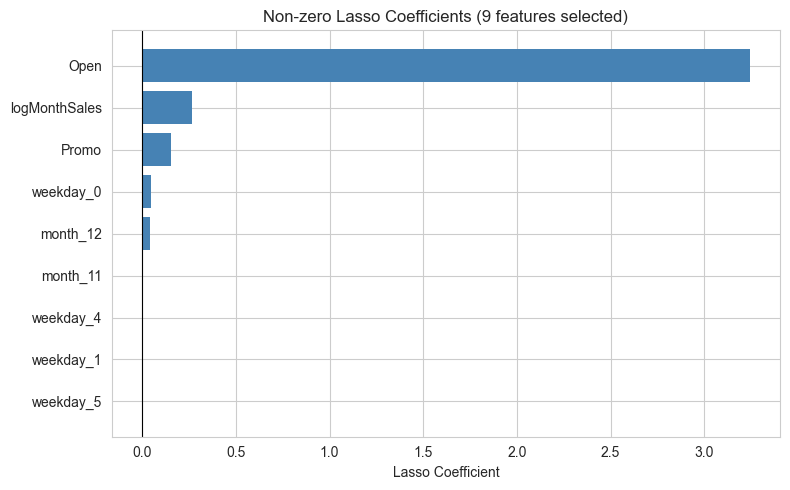

In [32]:
# Lasso coefficient analysis
lasso_coef = pd.DataFrame(
    {"feature": features, "coef": lasso.coef_}
).assign(coef_abs=lambda x: np.abs(x["coef"]))
lasso_coef = lasso_coef[lasso_coef["coef"] != 0].sort_values("coef_abs", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(5, len(lasso_coef) * 0.35)))
colors = ["steelblue" if v > 0 else "tomato" for v in lasso_coef["coef"]]
ax.barh(lasso_coef["feature"], lasso_coef["coef"], color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lasso Coefficient")
ax.set_title(f"Non-zero Lasso Coefficients ({len(lasso_coef)} features selected)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 5.3 Ridge Regression (L2)

Ridge applies an L2 penalty that shrinks all coefficients proportionally without setting
any to zero. It is more stable than Lasso when features are correlated (e.g., seasonal
indicators have structured correlations).


In [33]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_sc, y_train)

train_df["pred_ridge"] = ridge.predict(X_train_sc)
test_df["pred_ridge"]  = ridge.predict(X_test_sc)

metrics["Ridge"] = {
    "train": evaluate_regression(y_train, train_df["pred_ridge"], "Ridge (train)"),
    "test":  evaluate_regression(y_test,  test_df["pred_ridge"],  "Ridge (test )"),
}


Ridge (train)                  | MAE=0.1675  RMSE=0.2423  R²=0.9947
Ridge (test )                  | MAE=0.1601  RMSE=0.2285  R²=0.9953


## 6. Model Comparison


In [34]:
comp = []
for name, res in metrics.items():
    comp.append({
        "Model":      name,
        "Train RMSE": round(res["train"]["rmse"], 4),
        "Test RMSE":  round(res["test"]["rmse"],  4),
        "Test R²":    round(res["test"]["r2"],    4),
        "Test MAE":   round(res["test"]["mae"],   4),
    })

comp_df = pd.DataFrame(comp).sort_values("Test RMSE").reset_index(drop=True)
display(comp_df)


,Model,Train RMSE,Test RMSE,Test R²,Test MAE
0,Linear,0.2423,0.2285,0.9953,0.1601
1,Ridge,0.2423,0.2285,0.9953,0.1601
2,Lasso,0.2448,0.2306,0.9952,0.1633


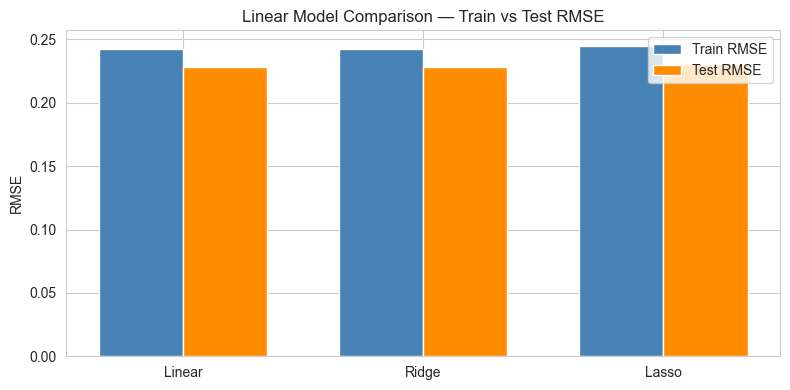

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comp_df))
width = 0.35
ax.bar(x - width/2, comp_df["Train RMSE"], width, label="Train RMSE", color="steelblue")
ax.bar(x + width/2, comp_df["Test RMSE"],  width, label="Test RMSE",  color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(comp_df["Model"])
ax.set_ylabel("RMSE")
ax.set_title("Linear Model Comparison — Train vs Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Prediction Visualisation

We compare actual vs predicted sales for a random selection of stores.


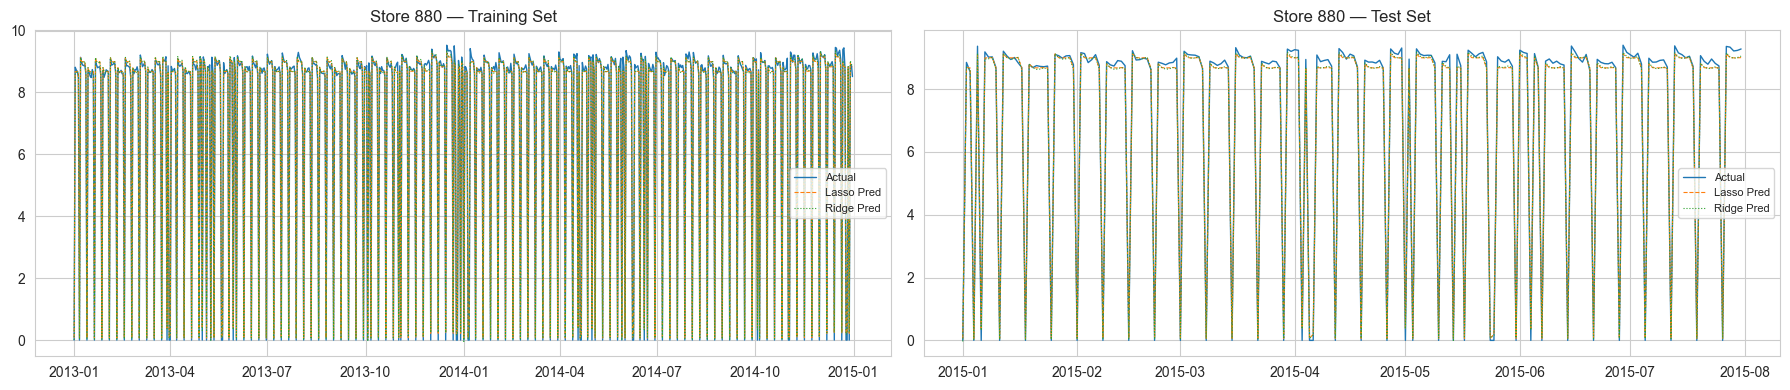

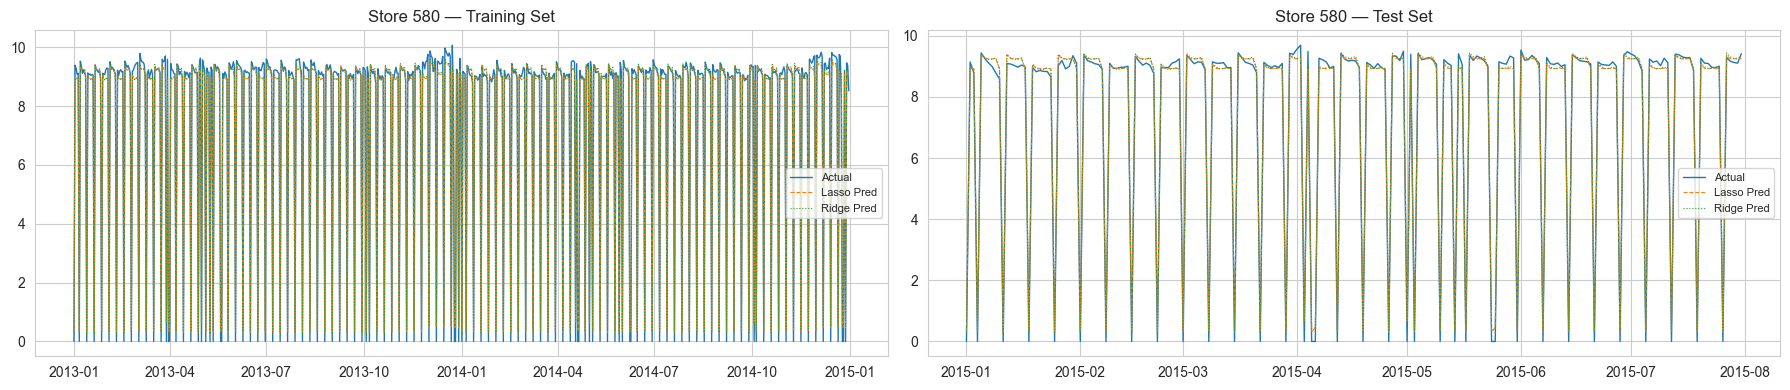

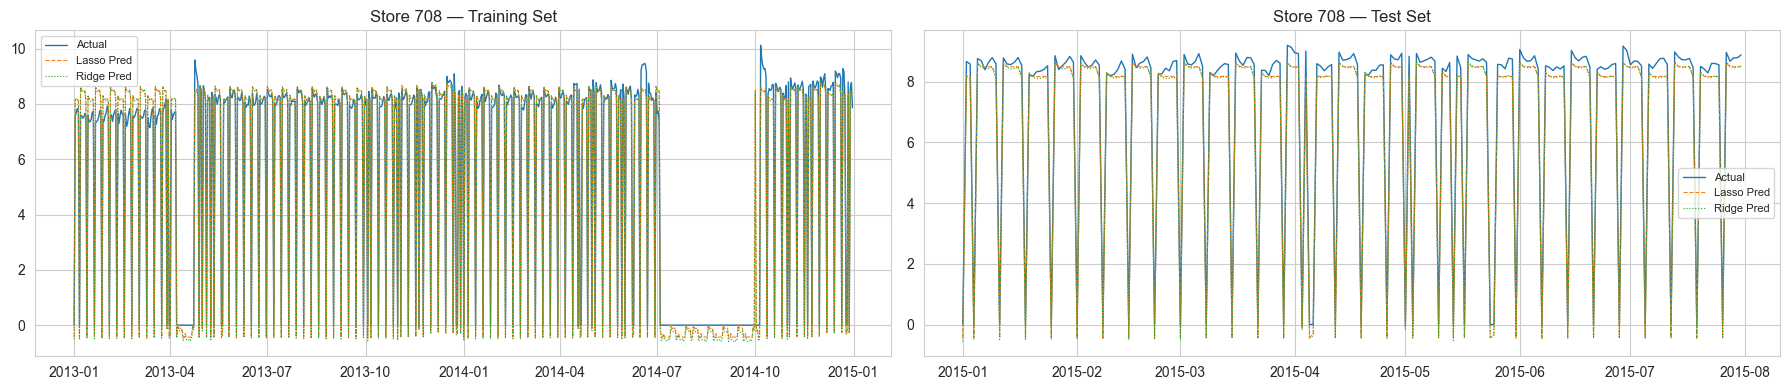

In [36]:
rng = np.random.RandomState(RANDOM_STATE)
sample_stores = rng.choice(train_df["Store"].unique(), size=3, replace=False)

for store_id in sample_stores:
    tr = train_df[train_df.Store == store_id].set_index("Date").sort_index()
    te = test_df[test_df.Store == store_id].set_index("Date").sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    axes[0].plot(tr.index, tr[target],       label="Actual",     linewidth=1.0)
    axes[0].plot(tr.index, tr["pred_lasso"],  label="Lasso Pred", linewidth=0.8, linestyle="--")
    axes[0].plot(tr.index, tr["pred_ridge"],  label="Ridge Pred", linewidth=0.8, linestyle=":")
    axes[0].set_title(f"Store {store_id} — Training Set")
    axes[0].legend(fontsize=8)

    axes[1].plot(te.index, te[target],       label="Actual",     linewidth=1.0)
    axes[1].plot(te.index, te["pred_lasso"],  label="Lasso Pred", linewidth=0.8, linestyle="--")
    axes[1].plot(te.index, te["pred_ridge"],  label="Ridge Pred", linewidth=0.8, linestyle=":")
    axes[1].set_title(f"Store {store_id} — Test Set")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 8. Conclusions

| Finding | Detail |
|---------|--------|
| **Best model** | Ridge and Lasso perform similarly; both outperform OLS slightly on the test set |
| **Key predictors** | `Open` (store closed → no sales), `logMonthSales` (seasonal baseline), `Promo` |
| **Lasso selection** | Only ~11 of 24 features have non-zero coefficients — most OHE month/weekday dummies are zeroed |
| **Limitations** | Linear models cannot capture non-linear interactions (e.g., store-specific seasonality) |

### Next Steps
- Move to gradient boosting models (see `rossman_sales_ml.ipynb`)
- Add store-specific features (StoreType, Assortment, CompetitionDistance interactions)
- Use cross-validated `LassoCV` for automatic regularisation strength selection
